In [1]:
import json
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')
from polysight.collection import decode

# In-place synchronization from collected raw data

idx, received bytes, timestamp
['1', '1456', '1750898500.7040148']
['2', '1456', '1750898500.7040148']
['3', '1456', '1750898500.7040148']
['4', '1456', '1750898500.7040148']
['5', '1456', '1750898500.7040148']


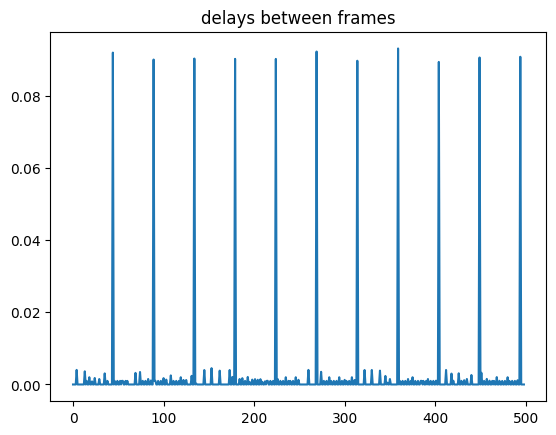

In [2]:
fileDir = '../data/unsynced/20250625_174140_multi_7'
# fileDir = './data/unsynced/20250626_175748_multi_11'


with open(os.path.join(fileDir, 'RH', '0_0_log.csv'), 'r') as f:
    reader = csv.reader(f)
    lines = [row for row in reader]

print('idx,', 'received bytes,', 'timestamp')
for _ in range(5):
    print(lines[_])

idx_list = [int(row[0]) for row in lines]
bytes_list = [int(row[1]) for row in lines]
timestamp_list = [float(row[2]) for row in lines]

plt.figure()
plt.plot([timestamp_list[i] - timestamp_list[i-1] for i in range(1, 500)])
plt.title('delays between frames')
plt.show()

16 frames(1 chirp per frame) captured at each SAR antenna location for higher SNR. The motion stage won't stop, those 16 chirps were captured very fast continuously which are considered captured at the same location. Chirps at the same location will be synced and coherently averaged for higher SNR (bi-static channel is a bit noisier).

The delay between frames shows transition between positions on the motion stage, and it's used for separate the antenna locations.

In [3]:
cfg_collection = json.load(open(os.path.join(fileDir, 'data_collection_cfg.json'), 'r'))

# RH
radar_name = 'RH'
cfg_decode = {
    'method': 'alignchirp',
    'fft_upscale': 64,  # for sync chirps at the same location, higher sync resolution
    'save': True,
    'saveSubDir': '_adcData',
}
# the collection goes line by line and each line is a .bin file containing num_triggers*total_x frames
# sync and coherently average 16 chirps at each SAR locations, saved in _adcData
decode.decodeDataLine_multiprocess(fileDir, radar_name, cfg_collection, cfg_decode, num_core=6)
# combine synced line data into a single 2D array of total_y * total_x frames
decode.combineLine(os.path.join(fileDir, cfg_decode['saveSubDir'], radar_name), cfg_collection)

# RV
radar_name = 'RV'
cfg_decode = {
    'method': 'alignchirp',
    'fft_upscale': 64,
    'save': True,
    'saveSubDir': '_adcData',
    'sync_ch': 1,
}
decode.decodeDataLine_multiprocess(fileDir, radar_name, cfg_collection, cfg_decode, num_core=6)
decode.combineLine(os.path.join(fileDir, cfg_decode['saveSubDir'], radar_name), cfg_collection)



RH 200
RV 200


Sometimes there will be below listed errors because there was a missing position in the collection. The reason can be that the radar went into fault mode, or the hardware trigger failed to trigger sometimes. 

idx 109 found no data, ../data/unsynced/20250626_205357_multi_12/RH/0_12.bin

An error occurred: list assignment index out of range. 
input: ../data/unsynced/20250626_150224_multi_10/RH/0_0.bin

Those can missing positions can cause mismatch of locations, however, as we are collecting a large 2D synthesized aperture, one single data point won't affect the result too much. The mismatched positions can be manually fixed during the decoding process.

# Fine-grind Synchronization of Radar Cube

In [4]:
import os
import matplotlib.pyplot as plt

import numpy as np
import scipy
import scipy.signal
from scipy.signal import ZoomFFT

from polysight.dsp import signal as dsp


(4, 200, 350, 256)
(4, 200, 350, 192)
The full bandwidth is noisier than partial bandwidth


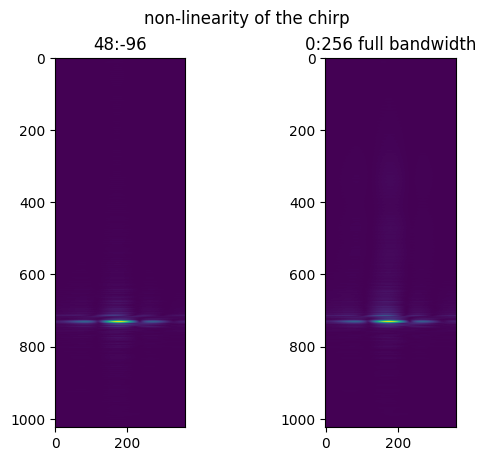

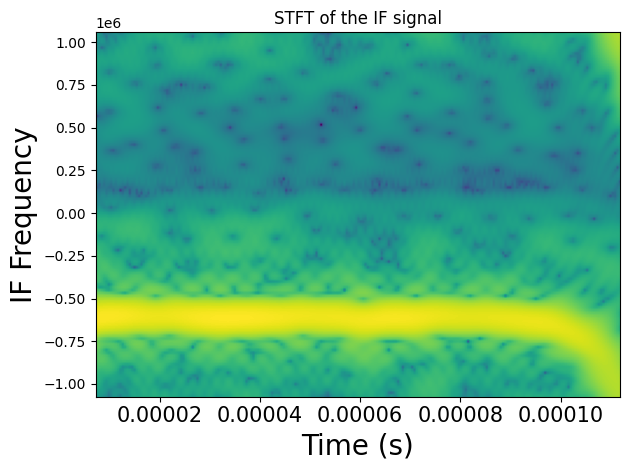

In [5]:
fileDir = '../data/unsynced/20250625_174140_multi_7'

radar_mode = 'RV'
# radar_mode = 'RH'

# adcData_ori shape: (num_chirps, total_y, total_x, num_samples)
adcData_ori = np.array([np.load(name) for name in [os.path.join(fileDir, 'adcData', radar_mode, '0_{x:d}.npy'.format(x=i)) for i in range(4)]])

# fullbandwidth is more noisy because of the chirp non-linearity, partial bandwidth is less noisy
# adcData shape: (num_chirps, total_y, total_x, partial_num_samples)
idx_adc_start = 0
idx_adc_end = 256-64
siglen = idx_adc_end - idx_adc_start
adcData = adcData_ori[:,:,:,idx_adc_start:idx_adc_end]
print(adcData_ori.shape)
print(adcData.shape)

num_vec, angle_steering_vec = dsp.gen_angle_steering_vec(90, 0.5, 4)

print('The full bandwidth is noisier than partial bandwidth')
f, axarr = plt.subplots(1,2)
sig = adcData_ori[:,70,160,:]
bf0 = angle_steering_vec @ np.fft.fft(sig[:,idx_adc_start:idx_adc_end], 1024)
axarr[0].imshow(np.abs(bf0).T)
axarr[0].set_title('48:-96')
bf1 = angle_steering_vec @ np.fft.fft(sig, 1024)
axarr[1].imshow(np.abs(bf1).T)
axarr[1].set_title('0:256 full bandwidth')
f.suptitle('non-linearity of the chirp')
plt.show()

plt.figure(dpi=100)
plt.specgram(sig[0,:], Fs=2150e3, NFFT=32, pad_to=128, noverlap=31)
# plt.xticks([])
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('IF Frequency', fontsize=20)
plt.xticks(fontsize=15)
plt.title('STFT of the IF signal')
plt.tight_layout()
plt.show()

Synchronization across the SAR radar cube

for different RX board (RV or RH), use different steering vector towards the reference peak

The reference peak does not nessaserily need to be directly direct-path

It could also be the null of object path. This comes useful when the object (imaging plane) is very close to the radar sensors that can significantly interfere with the direct path.

In [6]:
# choose the steering vector for beamforming

# RV
ang_vec_0 = angle_steering_vec[120,:]

find_peak_height = 3e4
find_peak_dist = 5
# find_peak_prominence = 0.2e4
find_peak_prominence = 0


# # RH
# ang_vec_0 = angle_steering_vec[241,:]

# find_peak_height = 1e5
# find_peak_dist = 2
# find_peak_prominence = 0


idx_fft_start = 0
idx_fft_end = 1024
ref_idx_to_align = 256
fs_zoom = 1024
ns_zoom = 2048

transform = ZoomFFT(siglen, [idx_fft_start, idx_fft_end], ns_zoom, fs=fs_zoom)

transform0 = ZoomFFT(siglen, [0, siglen], fs_zoom, fs=siglen)

print(adcData.shape)

from itertools import product

adcData_aligned = np.zeros(adcData_ori.shape, dtype=np.complex64)

# use maxval for alignment
for i, j in product(range(adcData_ori.shape[1]), range(adcData_ori.shape[2])):
    sig = adcData[:,i,j,:]
    sigfft = ang_vec_0 @ transform0(sig)
    peaks, _ = scipy.signal.find_peaks(np.abs(sigfft), height=find_peak_height, distance=find_peak_dist, prominence=find_peak_prominence)

    if peaks.size:
        idx_max = peaks[0]
    else:
        idx_max = np.argmax(np.abs(sigfft))

    _idx_fft_start = idx_max-1
    _idx_fft_end = idx_max+1
    _ns_zoom = 100
    _transform = ZoomFFT(siglen, [_idx_fft_start, _idx_fft_end], _ns_zoom, fs=fs_zoom)
    sigfft = ang_vec_0 @ _transform(sig)

    idxmax = np.argmax(np.abs(sigfft))
    df = (idxmax/_ns_zoom*abs(_idx_fft_start-_idx_fft_end)+_idx_fft_start-ref_idx_to_align)/fs_zoom
    da = 0
    sig_shifted = dsp.move_offset(adcData_ori[:,i,j], df, da)
    adcData_aligned[:,i,j] = sig_shifted


# remove the phase offset afterwards
# fftData_aligned = transform0(adcData_aligned[:,:,:,idx_adc_start:idx_adc_end])
for i, j in product(range(adcData_ori.shape[1]), range(adcData_ori.shape[2])):
    sig = adcData_aligned[:,i,j,idx_adc_start:idx_adc_end]
    sigfft = ang_vec_0 @ np.fft.fft(sig, fs_zoom*1, axis=-1)
    phase_diff = np.angle(sigfft[ref_idx_to_align*1])
    adcData_aligned[:,i,j,:] *= np.exp(-1j*phase_diff)




(4, 200, 350, 192)


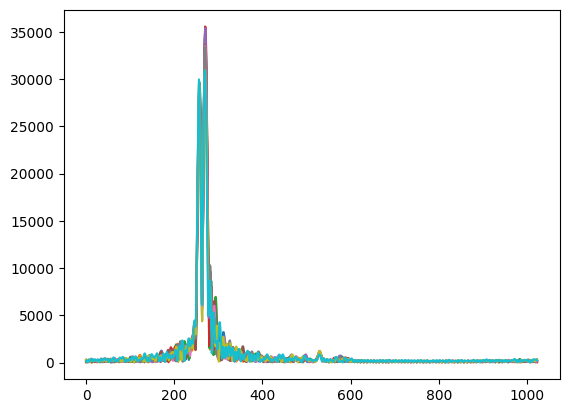

In [7]:
plt.figure()
for i in range(10):
    plt.plot(np.abs(np.fft.fft(ang_vec_0 @ adcData_aligned[:,70,160+i,16:-96], n=1024, axis=-1)))
plt.show()

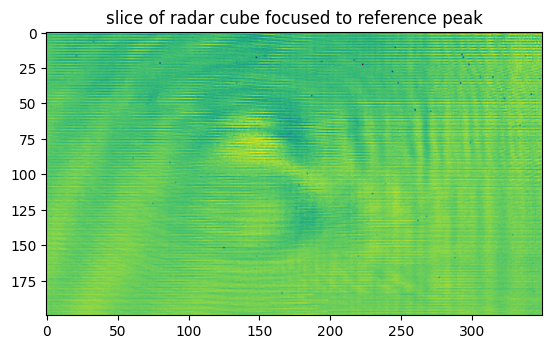

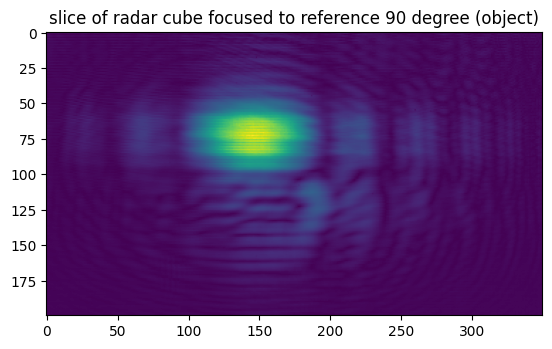

In [8]:
plt.figure()
plt.imshow(np.abs(np.fft.fft(np.sum(np.conj(ang_vec_0)[:,None,None,None] * adcData_aligned[:,:,:,16:-96], axis=0), n=1024, axis=-1)[:,:,256]))
plt.title('slice of radar cube focused to reference peak')
plt.show()


plt.figure()
plt.imshow(np.abs(np.fft.fft(np.sum(adcData_aligned[:,:,:,16:-96], axis=0), n=1024, axis=-1)[:,:,270]))
plt.title('slice of radar cube focused to reference 90 degree (object)')
plt.show()

In [13]:
# # save the results

# saveName = os.path.join(fileDir, 'adcData', radar_mode, 'tx0.npy')
# print(saveName)
# np.save(saveName, adcData_aligned)

# align the reference peak between VRX and HRX radar cubes

(4, 200, 350, 256)


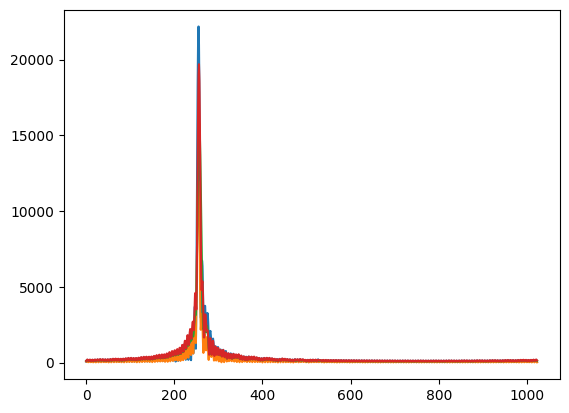

In [14]:
from polysight.dsp.signal import shift_aveAdcData_to_argmax

fileDir = '../data/unsynced/20250625_174140_multi_7'

plt.figure()
adcData = shift_aveAdcData_to_argmax(fileDir, 'RH', 241, fileName_shifted='tx0_shifted_argmax_tmp')
print(adcData.shape)
plt.plot(np.abs(np.fft.fft(np.mean(adcData[:,:,:,16:-64], axis=(1,2)), 1024, -1)).T)
adcData = shift_aveAdcData_to_argmax(fileDir, 'RV', 120, fileName_shifted='tx0_shifted_argmax_tmp')
print(adcData.shape)
plt.plot(np.abs(np.fft.fft(np.mean(adcData[:,:,:,16:-64], axis=(1,2)), 1024, -1)).T)
plt.show()